# Embeddings I — Rows of a Table as Vectors

A row of a spreadsheet is already a vector: a home with 3 bedrooms, 1,800 square feet, and a
\$210,000 sale price is the point $(3,\ 1800,\ 210000)$ in three dimensions. Once rows are
vectors we can ask a geometric question about them — *which two homes are most alike?* — and
answer it with the angle between them. This notebook does exactly that, and discovers that the
obvious approach gives a badly misleading answer until the columns are put on a common scale.

That failure is the point of the notebook. It is the same failure that motivates the
preprocessing work in the next section, and the same idea — represent a thing as a vector,
compare with angles — that the image and text notebooks build on.

## Learning objectives

- Interpret a row of a table as a vector in feature space
- Compute pairwise cosine similarity with `sklearn.metrics.pairwise.cosine_similarity`
- Explain why a large-magnitude column dominates the cosine and forces every pair toward 1
- Standardize features and show that cosine similarity only becomes informative afterward
- Read a similarity histogram to judge whether a representation separates its data at all

## Background

This notebook assumes only that a table has rows and numeric columns. Vectors, dot products, and
norms are introduced in section 2 where they are first needed. `StandardScaler` is used in
section 3 as a tool and explained just enough to follow the argument.

**Prerequisites:** none. `U1-2_Preprocess` develops the scalers used here at greater length, and
`U1-1_Embeddings-2_Images` / `-3_Text` apply the same cosine-similarity idea to data that is not
already numeric.

**Dataset:** `Real Estate Data.csv` — the raw (not preprocessed) real-estate file, subsampled to
50 homes so every pairwise comparison can be inspected by hand.

**References:** https://scikit-learn.org/stable/modules/metrics.html#cosine-similarity

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# Shared course helpers (msds565_helpers.py lives in the repo root).
# Notebooks sit two folders below the root, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds565_helpers as helpers

## 1. Load and subsample the data

We keep only the numeric columns — cosine similarity needs numbers, and the categorical columns
have no meaningful magnitude yet — drop any row with a missing value, and take a random sample of
50 homes. Fifty is small enough that the $50 \times 50$ similarity matrix and its
$\binom{50}{2} = 1{,}225$ distinct pairs stay inspectable.

Look closely at the column magnitudes in the output below. `Sale Price` runs into the hundreds of
thousands while `Overall Qual` is a single digit. That spread is what section 2 runs into.

In [2]:
data_folder = 'C:/Users/Graham West/Python Notebooks/Meharry Teaching/Datasets/'

df = pd.read_csv(data_folder + 'Real Estate/Real Estate Data.csv', index_col=0, header=0)

df = df.rename(columns = {'OvQual':'Overall Qual',
                          'Built':'Year',
                          'Garage Yr Built':'Year Garage'})

df = df.select_dtypes(include=np.number)
df = df.dropna(axis=0)
df = df.sample(50)

df = df.reset_index(drop=True)

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Lot Frontage              50 non-null     float64
 1   Lot Area                  50 non-null     int64  
 2   Overall Qual              50 non-null     int64  
 3   Overall Cond              50 non-null     int64  
 4   Year                      50 non-null     int64  
 5   Year Remod Add            50 non-null     int64  
 6   Masonry/Veneer Area       50 non-null     float64
 7   Basement Finished Area    50 non-null     int64  
 8   Basement Unfinished Area  50 non-null     int64  
 9   Basement Area             50 non-null     int64  
 10  1st Floor Area            50 non-null     int64  
 11  2nd Floor Area            50 non-null     int64  
 12  Living Area Above Grade   50 non-null     int64  
 13  Basement Full Baths       50 non-null     int64  
 14  Basement Hal

,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year,Year Remod Add,Masonry/Veneer Area,Basement Finished Area,Basement Unfinished Area,Basement Area,1st Floor Area,2nd Floor Area,Living Area Above Grade,Basement Full Baths,Basement Half baths,Full Baths Above Grade,Half Baths Above Grade,Bedrooms Above Grade,Kitchens Above Grade,Total Rooms Above Grade,Fireplaces,Year Garage,Garage Cars,Garage Area,Wood Deck Area,Open Porch Area,Enclosed Porch Area,3 Season Porch Area,Screen Porch Area,Pool Area,Sale Price
0,50.0,6000,6,6,1925,1980,0.0,397,706,1103,1103,0,1103,0,0,1,0,2,1,5,1,1976.0,2,440,166,120,0,0,0,0,110500
1,54.0,7244,5,7,1970,1970,0.0,619,149,768,768,0,768,1,0,1,0,2,1,5,0,1987.0,2,624,104,0,0,0,0,0,129500
2,34.0,4060,6,5,1998,1999,0.0,266,1139,1405,1337,0,1337,1,0,2,0,2,1,5,0,1998.0,2,511,144,68,0,0,0,0,181000
3,114.0,14803,10,5,2007,2008,816.0,1636,442,2078,2084,0,2084,1,0,2,0,2,1,7,1,2007.0,3,1220,188,45,0,0,0,0,385000
4,71.0,9204,5,5,1963,1963,0.0,25,247,1144,1144,0,1144,1,0,1,1,3,1,6,0,1962.0,1,336,0,88,0,0,0,0,124000


## 2. Cosine similarity on the raw features

Treat each row as a vector $\mathbf{a} \in \mathbb{R}^d$. The **cosine similarity** of two rows is
the cosine of the angle between them:

$$\cos\theta = \frac{\mathbf{a}\cdot\mathbf{b}}{\lVert\mathbf{a}\rVert\,\lVert\mathbf{b}\rVert}
= \frac{\sum_{j=1}^{d} a_j b_j}{\sqrt{\sum_{j=1}^{d} a_j^2}\ \sqrt{\sum_{j=1}^{d} b_j^2}}$$

It ranges from $-1$ (opposite directions) through $0$ (perpendicular) to $1$ (same direction).
Unlike Euclidean distance it ignores *length* and measures only *direction*, which is why it is
the standard way to compare embeddings: a long document and a short one about the same topic
should count as similar.

Because the similarity matrix is symmetric with a diagonal of 1s, the histogram below takes only
the strict upper triangle (`np.triu_indices` with `k=1`) — the $1{,}225$ genuinely distinct pairs.

[1.         0.99994932 0.99941497 0.99959208 0.99977942 0.99290788
 0.99983629 0.99992101 0.99993327 0.99913689 0.99980413 0.99945584
 0.99983114 0.99983592 0.9995323  0.99981115 0.99962893 0.99991968
 0.9997285  0.99936405 0.99994143 0.99983925 0.99984383 0.99973113
 0.99991876 0.9992324  0.99918602 0.99977365 0.99936719 0.99972623
 0.99977535 0.99992948 0.99995199 0.99989089 0.99944051 0.99941909
 0.99991473 0.99953645 0.99990253 0.99965673 0.9998506  0.99990681
 0.99984622 0.99981028 0.99992665 0.99961183 0.99936084 0.99970941
 0.99980962 0.99988131]


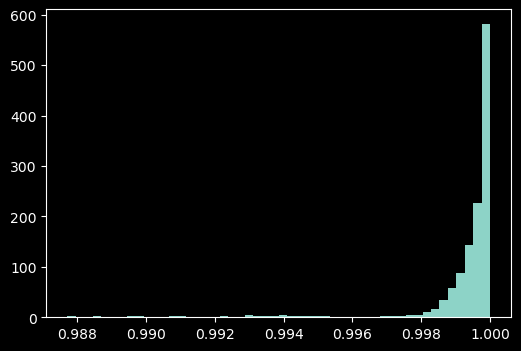

In [3]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(df)
print(cosine_sim[0,:])

idx = np.triu_indices(cosine_sim.shape[0], k=1)
cosine_sim_flat = cosine_sim[idx]
plt.figure(figsize=(6,4))
plt.hist(cosine_sim_flat, bins=50);

Every pair is crammed against 1.0. By this measure all fifty homes are nearly identical, which is
plainly false.

The formula explains it. `Sale Price` is on the order of $10^5$ while `Overall Qual` is on the
order of $10^0$, and the sums above are **unweighted**. A single term $a_j b_j$ where both factors
are ~$10^5$ contributes ~$10^{10}$, while a term where both are ~$10^0$ contributes ~$1$. The
price column therefore accounts for essentially the entire numerator *and* the entire denominator,
so the cosine collapses to a comparison of one feature with itself — and since every price is a
positive number, every angle comes out near zero.

Two more things follow from this. The features are all positive, so the vectors are confined to
one orthant and the cosine can never even reach 0, let alone go negative. And the result is not a
property of the homes at all: change the price column from dollars to thousands of dollars and
every number in this histogram moves.

## 3. Standardize the features

The fix is to give every column the same footing. **Standardization** replaces each value with its
z-score — how many standard deviations it sits from its column's mean:

$$z_j = \frac{x_j - \mu_j}{\sigma_j}$$

Every column now has mean 0 and standard deviation 1, so no column can dominate a sum by sheer
magnitude. Centering at zero matters just as much as rescaling: values become both positive and
negative, the vectors are no longer trapped in a single orthant, and the full $[-1, 1]$ range of
the cosine becomes reachable.

In [4]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()

df_ss = pd.DataFrame()
for c in df.columns:
    df_ss[c] = std_scaler.fit_transform(df[[c]])[:,0]
# end

df_ss.head()

,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year,Year Remod Add,Masonry/Veneer Area,Basement Finished Area,Basement Unfinished Area,Basement Area,1st Floor Area,2nd Floor Area,Living Area Above Grade,Basement Full Baths,Basement Half baths,Full Baths Above Grade,Half Baths Above Grade,Bedrooms Above Grade,Kitchens Above Grade,Total Rooms Above Grade,Fireplaces,Year Garage,Garage Cars,Garage Area,Wood Deck Area,Open Porch Area,Enclosed Porch Area,3 Season Porch Area,Screen Porch Area,Pool Area,Sale Price
0,-0.857634,-0.944980,-0.216851,0.298511,-1.606033,-0.621610,-0.642617,-0.097810,0.155758,-0.053730,-0.283076,-0.596181,-0.734270,-0.850963,0.0,-1.128152,-0.623610,-1.052274,-0.142857,-0.798974,0.928477,-0.339978,-0.030875,-0.516963,0.399430,0.969365,-0.3868,0.0,-0.328663,0.0,-1.014532
1,-0.692067,-0.616508,-0.894509,1.293548,-0.160603,-1.227468,-0.642617,0.379207,-0.856817,-0.780101,-1.117706,-0.596181,-1.499945,1.175139,0.0,-1.128152,-0.623610,-1.052274,-0.142857,-0.798974,-0.928477,0.138252,-0.030875,0.238807,-0.066597,-0.952072,-0.3868,0.0,-0.328663,0.0,-0.758627
2,-1.519899,-1.457227,-0.216851,-0.696526,0.738775,0.529520,-0.642617,-0.379293,0.942913,0.601089,0.299919,-0.596181,-0.199441,1.175139,0.0,0.886405,-0.623610,-1.052274,-0.142857,-0.798974,-0.928477,0.616482,-0.030875,-0.225335,0.234066,0.136742,-0.3868,0.0,-0.328663,0.0,-0.064989
3,1.791428,1.379407,2.493784,-0.696526,1.027861,1.074792,3.959588,2.564460,-0.324170,2.060336,2.161018,-0.596181,1.507899,1.175139,0.0,0.886405,-0.623610,-1.052274,-0.142857,0.510820,0.928477,1.007762,1.512893,2.686845,0.564794,-0.231533,-0.3868,0.0,-0.328663,0.0,2.682625
4,0.011590,-0.098980,-0.894509,-0.696526,-0.385448,-1.651568,-0.642617,-0.897135,-0.678662,0.035169,-0.180928,-0.596181,-0.640561,1.175139,0.0,-1.128152,1.603567,0.495188,-0.142857,-0.144077,-0.928477,-0.948635,-1.574644,-0.944138,-0.848319,0.456982,-0.3868,0.0,-0.328663,0.0,-0.832705


## 4. Cosine similarity after standardization

The same calculation, on the standardized rows.

[ 1.          0.39705808  0.12411392 -0.46057898  0.18817978 -0.23771791
 -0.17850538  0.22014145  0.1708626   0.31929213  0.2289272  -0.36364721
 -0.41052219 -0.1983505   0.24721014 -0.11963394 -0.28575682  0.18800621
  0.28833539  0.17694956  0.29258757  0.2700405   0.02909573 -0.36049984
  0.09879745  0.18225746  0.09339788  0.39170321 -0.16123907 -0.40669575
 -0.44599424 -0.031202    0.53090695  0.52223242 -0.61348862 -0.56295707
  0.57243035 -0.42772229  0.25828835  0.34395483 -0.21329851 -0.08528873
 -0.10454074 -0.23082281  0.14173738 -0.26922966  0.13343457 -0.26240773
 -0.1843615   0.36565029]


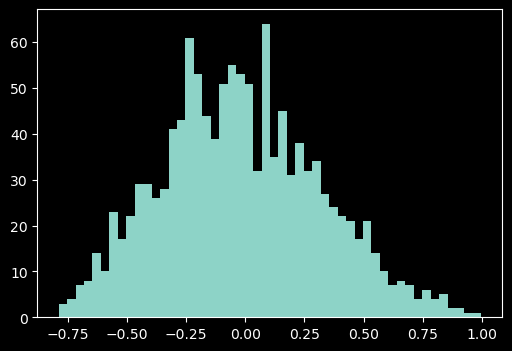

In [5]:
cosine_sim_ss = cosine_similarity(df_ss)
print(cosine_sim_ss[0,:])

idx = np.triu_indices(cosine_sim_ss.shape[0], k=1)
cosine_sim_ss_flat = cosine_sim_ss[idx]
plt.figure(figsize=(6,4))
plt.hist(cosine_sim_ss_flat, bins=50);

Now the histogram spreads across the range and includes negative values. A pair near $+1$ is
genuinely a pair of homes that are above or below average on the *same* features; a pair near
$-1$ is a pair that are mirror images, one above average wherever the other is below.

The measurement did not change — only the representation did. This is the general lesson: a
similarity is only as meaningful as the space it is computed in, and getting that space right is
preprocessing, not modeling.

## 5. Inspecting the most similar pairs

A histogram says the representation now separates the data; it does not say whether the answers
are *correct*. For that we pull out the pairs the model calls similar and read them side by side.

We take the strict upper triangle again so each pair is shown once rather than twice.

In [6]:
# Strict upper triangle: each unordered pair once, no self-comparisons.
rows, cols = np.triu_indices(cosine_sim_ss.shape[0], k=1)
mask = cosine_sim_ss[rows, cols] > 0.75

rows = rows[mask]
cols = cols[mask]

print(f'{len(rows)} pairs with cosine similarity > 0.75')

for r, c in zip(rows, cols):
    print(f'--- rows {r} and {c}:  cosine = {cosine_sim_ss[r, c]:.3f} ---')
    display(df.iloc[[r, c], :])
# end

20 pairs with cosine similarity > 0.75
--- rows 1 and 32:  cosine = 0.777 ---


,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year,Year Remod Add,Masonry/Veneer Area,Basement Finished Area,Basement Unfinished Area,Basement Area,1st Floor Area,2nd Floor Area,Living Area Above Grade,Basement Full Baths,Basement Half baths,Full Baths Above Grade,Half Baths Above Grade,Bedrooms Above Grade,Kitchens Above Grade,Total Rooms Above Grade,Fireplaces,Year Garage,Garage Cars,Garage Area,Wood Deck Area,Open Porch Area,Enclosed Porch Area,3 Season Porch Area,Screen Porch Area,Pool Area,Sale Price
1,54.0,7244,5,7,1970,1970,0.0,619,149,768,768,0,768,1,0,1,0,2,1,5,0,1987.0,2,624,104,0,0,0,0,0,129500
32,60.0,7200,5,7,1972,1972,0.0,632,148,780,780,0,780,0,0,1,0,2,1,4,0,1973.0,1,352,196,0,0,0,0,0,124900


--- rows 1 and 38:  cosine = 0.884 ---


,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year,Year Remod Add,Masonry/Veneer Area,Basement Finished Area,Basement Unfinished Area,Basement Area,1st Floor Area,2nd Floor Area,Living Area Above Grade,Basement Full Baths,Basement Half baths,Full Baths Above Grade,Half Baths Above Grade,Bedrooms Above Grade,Kitchens Above Grade,Total Rooms Above Grade,Fireplaces,Year Garage,Garage Cars,Garage Area,Wood Deck Area,Open Porch Area,Enclosed Porch Area,3 Season Porch Area,Screen Porch Area,Pool Area,Sale Price
1,54.0,7244,5,7,1970,1970,0.0,619,149,768,768,0,768,1,0,1,0,2,1,5,0,1987.0,2,624,104,0,0,0,0,0,129500
38,74.0,8740,5,6,1982,1982,0.0,672,168,840,860,0,860,1,0,1,0,2,1,4,0,1996.0,2,528,0,0,0,0,0,0,137000


--- rows 3 and 11:  cosine = 0.945 ---


...

,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year,Year Remod Add,Masonry/Veneer Area,Basement Finished Area,Basement Unfinished Area,Basement Area,1st Floor Area,2nd Floor Area,Living Area Above Grade,Basement Full Baths,Basement Half baths,Full Baths Above Grade,Half Baths Above Grade,Bedrooms Above Grade,Kitchens Above Grade,Total Rooms Above Grade,Fireplaces,Year Garage,Garage Cars,Garage Area,Wood Deck Area,Open Porch Area,Enclosed Porch Area,3 Season Porch Area,Screen Porch Area,Pool Area,Sale Price
35,94.0,12220,10,5,2009,2009,305.0,1436,570,2006,2020,0,2020,1,0,2,1,3,1,9,1,2009.0,3,900,156,54,0,0,0,0,402861
37,71.0,9520,8,5,2007,2008,338.0,1513,125,1638,1646,0,1646,1,0,2,0,3,1,7,1,2008.0,3,800,192,44,0,0,0,0,293077


--- rows 40 and 45:  cosine = 0.882 ---


,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year,Year Remod Add,Masonry/Veneer Area,Basement Finished Area,Basement Unfinished Area,Basement Area,1st Floor Area,2nd Floor Area,Living Area Above Grade,Basement Full Baths,Basement Half baths,Full Baths Above Grade,Half Baths Above Grade,Bedrooms Above Grade,Kitchens Above Grade,Total Rooms Above Grade,Fireplaces,Year Garage,Garage Cars,Garage Area,Wood Deck Area,Open Porch Area,Enclosed Porch Area,3 Season Porch Area,Screen Porch Area,Pool Area,Sale Price
40,75.0,11957,8,5,2006,2006,53.0,24,1550,1574,1574,0,1574,0,0,2,0,3,1,7,1,2006.0,3,824,144,104,0,0,0,0,232000
45,84.0,11670,9,5,2006,2006,302.0,0,1905,1905,1905,0,1905,0,0,2,0,3,1,8,1,2006.0,3,788,0,191,0,0,0,0,320000


--- rows 40 and 48:  cosine = 0.777 ---


,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year,Year Remod Add,Masonry/Veneer Area,Basement Finished Area,Basement Unfinished Area,Basement Area,1st Floor Area,2nd Floor Area,Living Area Above Grade,Basement Full Baths,Basement Half baths,Full Baths Above Grade,Half Baths Above Grade,Bedrooms Above Grade,Kitchens Above Grade,Total Rooms Above Grade,Fireplaces,Year Garage,Garage Cars,Garage Area,Wood Deck Area,Open Porch Area,Enclosed Porch Area,3 Season Porch Area,Screen Porch Area,Pool Area,Sale Price
40,75.0,11957,8,5,2006,2006,53.0,24,1550,1574,1574,0,1574,0,0,2,0,3,1,7,1,2006.0,3,824,144,104,0,0,0,0,232000
48,118.0,13704,7,5,2001,2002,150.0,0,1541,1541,1541,0,1541,0,0,2,0,3,1,6,1,2001.0,3,843,468,81,0,0,0,0,205000


Read a few of these across their columns. The pairs should agree on the features that carry the
most variance — overall quality, living area, price — even where they differ on the smaller ones.
That agreement is what a cosine near 1 in standardized space actually means.

## 6. Review

- **A row of a table is a vector**, so two rows can be compared by the angle between them. Cosine
  similarity measures direction and ignores magnitude:
  $\cos\theta = \frac{\mathbf{a}\cdot\mathbf{b}}{\lVert\mathbf{a}\rVert\lVert\mathbf{b}\rVert}$.
- **On raw features it is nearly useless here.** The dot product is an unweighted sum, so a column
  measured in hundreds of thousands drowns out one measured in single digits, and every pair
  reports a similarity near 1.
- **All-positive features make it worse**, confining every vector to one orthant so the cosine
  cannot even reach 0.
- **Standardizing to $z_j = (x_j - \mu_j)/\sigma_j$ fixes both problems at once** — equal scale
  removes the domination, and centering at zero opens up the full $[-1, 1]$ range.
- **The similarity is a property of the representation, not of the homes.** Changing the units of
  one column changes every raw similarity. Any embedding you build later inherits this: get the
  space right before trusting distances in it.